In [123]:
    # Loan Amount Prediction Using Linear Regression
    # Yes! You can absolutely use the same dataset to predict loan amounts using linear regression. 
    # This is a classic regression problem where we'll predict a continuous value (loan amount) based on customer characteristics.
    
    # Here's a complete step-by-step implementation:
    
    # Step 1: Problem Setup
    # We'll predict LoanAmount using these features:
    
    # ApplicantIncome
    
    # CoapplicantIncome
    
    # Loan_Amount_Term
    
    # Credit_History
    
    # Property_Area (encoded)
    
    # Other relevant features
    
    # python


In [124]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
from sklearn.model_selection import train_test_split

### 1.load datasets

In [125]:
train_df = pd.read_csv('CSV_file\\train.csv')
test_df = pd.read_csv('CSV_file\\test.csv')

In [126]:
train_df.head()

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,LP001002,Male,No,0,Graduate,No,5849,0.0,NaN,360.0,1.0,Urban,Y
1,LP001003,Male,Yes,1,Graduate,No,4583,1508.0,128.0,360.0,1.0,Rural,N
2,LP001005,Male,Yes,0,Graduate,Yes,3000,0.0,66.0,360.0,1.0,Urban,Y
3,LP001006,Male,Yes,0,Not Graduate,No,2583,2358.0,120.0,360.0,1.0,Urban,Y
4,LP001008,Male,No,0,Graduate,No,6000,0.0,141.0,360.0,1.0,Urban,Y


In [127]:
test_df.head()

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area
0,LP001015,Male,Yes,0,Graduate,No,5720,0,110.0,360.0,1.0,Urban
1,LP001022,Male,Yes,1,Graduate,No,3076,1500,126.0,360.0,1.0,Urban
2,LP001031,Male,Yes,2,Graduate,No,5000,1800,208.0,360.0,1.0,Urban
3,LP001035,Male,Yes,2,Graduate,No,2340,2546,100.0,360.0,NaN,Urban
4,LP001051,Male,No,0,Not Graduate,No,3276,0,78.0,360.0,1.0,Urban


In [128]:
train_df.shape

(614, 13)

In [129]:
test_df.shape

(367, 12)

In [130]:
train_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 614 entries, 0 to 613
Data columns (total 13 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Loan_ID            614 non-null    object 
 1   Gender             601 non-null    object 
 2   Married            611 non-null    object 
 3   Dependents         599 non-null    object 
 4   Education          614 non-null    object 
 5   Self_Employed      582 non-null    object 
 6   ApplicantIncome    614 non-null    int64  
 7   CoapplicantIncome  614 non-null    float64
 8   LoanAmount         592 non-null    float64
 9   Loan_Amount_Term   600 non-null    float64
 10  Credit_History     564 non-null    float64
 11  Property_Area      614 non-null    object 
 12  Loan_Status        614 non-null    object 
dtypes: float64(4), int64(1), object(8)
memory usage: 62.5+ KB


In [131]:
train_df.isna().sum()

Loan_ID               0
Gender               13
Married               3
Dependents           15
Education             0
Self_Employed        32
ApplicantIncome       0
CoapplicantIncome     0
LoanAmount           22
Loan_Amount_Term     14
Credit_History       50
Property_Area         0
Loan_Status           0
dtype: int64

In [132]:
train_df.head()

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,LP001002,Male,No,0,Graduate,No,5849,0.0,NaN,360.0,1.0,Urban,Y
1,LP001003,Male,Yes,1,Graduate,No,4583,1508.0,128.0,360.0,1.0,Rural,N
2,LP001005,Male,Yes,0,Graduate,Yes,3000,0.0,66.0,360.0,1.0,Urban,Y
3,LP001006,Male,Yes,0,Not Graduate,No,2583,2358.0,120.0,360.0,1.0,Urban,Y
4,LP001008,Male,No,0,Graduate,No,6000,0.0,141.0,360.0,1.0,Urban,Y


<Axes: >

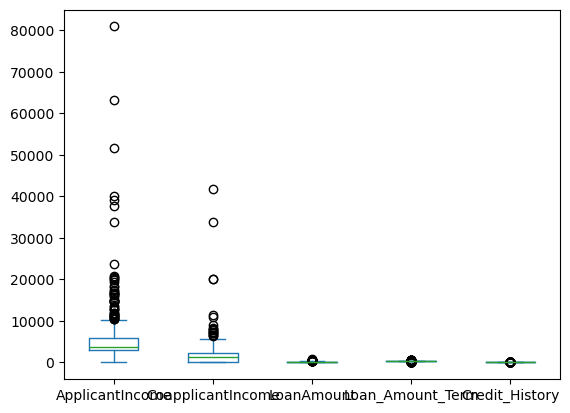

In [133]:
train_df.plot(kind = 'box')

In [134]:
train_df.head()

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,LP001002,Male,No,0,Graduate,No,5849,0.0,NaN,360.0,1.0,Urban,Y
1,LP001003,Male,Yes,1,Graduate,No,4583,1508.0,128.0,360.0,1.0,Rural,N
2,LP001005,Male,Yes,0,Graduate,Yes,3000,0.0,66.0,360.0,1.0,Urban,Y
3,LP001006,Male,Yes,0,Not Graduate,No,2583,2358.0,120.0,360.0,1.0,Urban,Y
4,LP001008,Male,No,0,Graduate,No,6000,0.0,141.0,360.0,1.0,Urban,Y


In [135]:
def EDA(df):
    # fillna with median
    cols = ['LoanAmount', 'Loan_Amount_Term', 'Credit_History', 'ApplicantIncome', 'CoapplicantIncome']
    for i in cols:
        if i in df.columns:
            median = df[i].median()
            df[i] = df[i].fillna(median)
        else:
            print(f'cloumn {i} is not found in DataFrame')

    # fill null with mode
    cols = ['Gender', 'Married', 'Dependents', 'Education', 'Self_Employed', 'Property_Area']
    for i in cols:
        df[i] = df[i].fillna(df[i].mode()[0])

     # convert categorical data into number
    label = {}
    cols = ['Gender', 'Married', 'Dependents', 'Education', 'Self_Employed', 'Property_Area']
    for i in cols:
        la = LabelEncoder()
        df[i] = la.fit_transform(df[i])
        label[i] = la
        
    return df, label    

train_df, labels = EDA(train_df)      
test_df, _ = EDA(test_df)

In [136]:
train_df.isna().sum()

Loan_ID              0
Gender               0
Married              0
Dependents           0
Education            0
Self_Employed        0
ApplicantIncome      0
CoapplicantIncome    0
LoanAmount           0
Loan_Amount_Term     0
Credit_History       0
Property_Area        0
Loan_Status          0
dtype: int64

In [137]:
train_df.head()

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,LP001002,1,0,0,0,0,5849,0.0,128.0,360.0,1.0,2,Y
1,LP001003,1,1,1,0,0,4583,1508.0,128.0,360.0,1.0,0,N
2,LP001005,1,1,0,0,1,3000,0.0,66.0,360.0,1.0,2,Y
3,LP001006,1,1,0,1,0,2583,2358.0,120.0,360.0,1.0,2,Y
4,LP001008,1,0,0,0,0,6000,0.0,141.0,360.0,1.0,2,Y


In [138]:
test_df.head()

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area
0,LP001015,1,1,0,0,0,5720,0,110.0,360.0,1.0,2
1,LP001022,1,1,1,0,0,3076,1500,126.0,360.0,1.0,2
2,LP001031,1,1,2,0,0,5000,1800,208.0,360.0,1.0,2
3,LP001035,1,1,2,0,0,2340,2546,100.0,360.0,1.0,2
4,LP001051,1,0,0,1,0,3276,0,78.0,360.0,1.0,2


In [139]:
## Add New feature
train_df['TotalIncome'] = train_df['ApplicantIncome']+ train_df['CoapplicantIncome']

In [140]:
train_df.head()

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status,TotalIncome
0,LP001002,1,0,0,0,0,5849,0.0,128.0,360.0,1.0,2,Y,5849.0
1,LP001003,1,1,1,0,0,4583,1508.0,128.0,360.0,1.0,0,N,6091.0
2,LP001005,1,1,0,0,1,3000,0.0,66.0,360.0,1.0,2,Y,3000.0
3,LP001006,1,1,0,1,0,2583,2358.0,120.0,360.0,1.0,2,Y,4941.0
4,LP001008,1,0,0,0,0,6000,0.0,141.0,360.0,1.0,2,Y,6000.0


### Predictors and target

In [141]:
features = ['TotalIncome', 'Loan_Amount_Term', 'Credit_History', 'Property_Area', 'Married', 'Dependents']
target = 'LoanAmount'

In [142]:
X = train_df[features]
Y = train_df[target]

In [143]:
X.shape, Y.shape

((614, 6), (614,))

In [144]:
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size = 0.2, random_state = 42)

In [145]:
X_train.shape, Y_train.shape

((491, 6), (491,))

In [146]:
X_test.shape, Y_test.shape

((123, 6), (123,))

### Create and train the model

In [147]:
model = LinearRegression()
model.fit(X_train, Y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [148]:
print('Model Coefficient: ')
for fe, coef in zip(features, model.coef_):
    print(f'{fe:20}: {coef:.2f}')

print()
print(f'Intercept : {model.intercept_:.2f}')

Model Coefficient: 
TotalIncome         : 0.01
Loan_Amount_Term    : 0.13
Credit_History      : 5.39
Property_Area       : -4.27
Married             : 14.41
Dependents          : 5.47

Intercept : 33.60


### Make Predictions

In [149]:
Y_pred = model.predict(X_test)

In [150]:
test_result = pd.DataFrame({
    'Y_actual': Y_test,
    'Y_pred': Y_pred
})

test_result.head()

,Y_actual,Y_pred
350,228.0,167.684815
377,130.0,130.293149
163,158.0,155.711414
609,71.0,109.103967
132,70.0,103.411671


In [151]:
### model Evaluation

In [152]:
print('R-square: ', r2_score(Y_test, Y_pred))
print('RMSE: ', np.sqrt(mean_squared_error(Y_test, Y_pred)))

R-square:  0.5503492938139974
RMSE:  49.474973086814


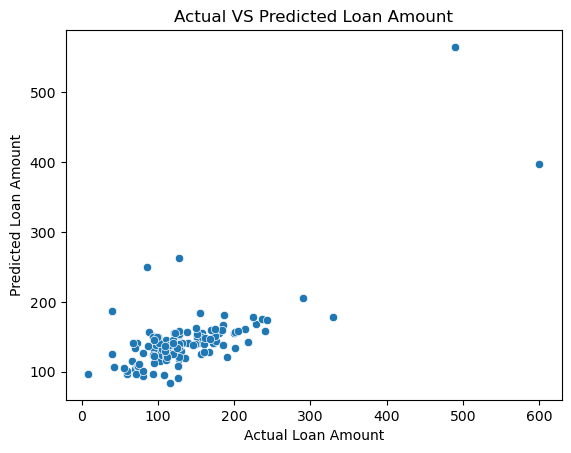

In [153]:
## visualizaton 
sns.scatterplot(x = Y_test, y = Y_pred)
plt.title('Actual VS Predicted Loan Amount')
plt.ylabel('Predicted Loan Amount')
plt.xlabel('Actual Loan Amount')
plt.show()

In [154]:
## Residual plot

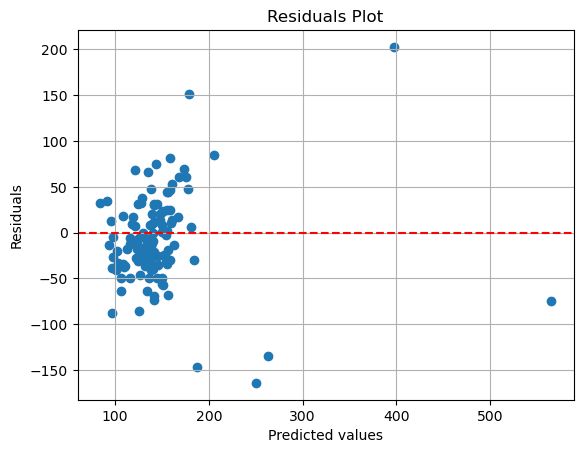

In [155]:
Residuals = Y_test - Y_pred
plt.scatter(x = Y_pred, y = Residuals)
plt.axhline(0, color = 'red', linestyle = '--')
plt.xlabel('Predicted values')
plt.ylabel('Residuals')
plt.title('Residuals Plot')
plt.grid()
plt.show()

In [156]:
### feature Importance Analysis

In [164]:
importance = pd.DataFrame({
    'Features': features,
    'Importance': np.abs(model.coef_)
}).sort_values(by = 'Importance', ascending = False)

In [173]:
importance

,Features,Importance
4,Married,14.409755
5,Dependents,5.468112
2,Credit_History,5.386860
3,Property_Area,4.266509
1,Loan_Amount_Term,0.131660
0,TotalIncome,0.007834


In [165]:
# PLot the importnace

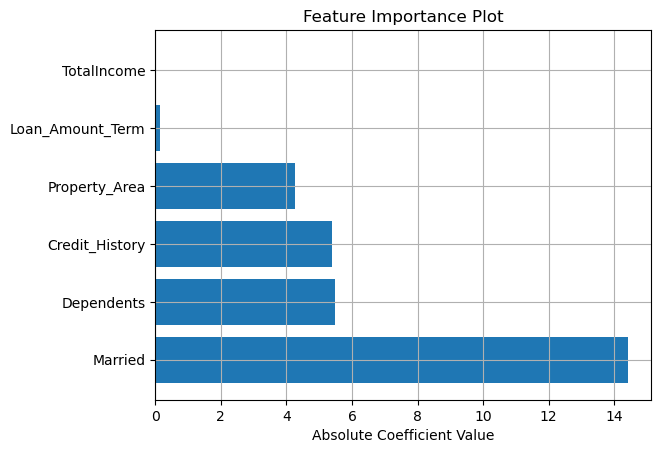

In [166]:
plt.barh(importance['Features'], importance['Importance'])
plt.xlabel('Absolute Coefficient Value')
plt.title('Feature Importance Plot')
plt.grid()
plt.show()

In [176]:
## make prediction on test_df
test_df['TotalIncome'] = test_df['ApplicantIncome']+test_df['CoapplicantIncome']

In [177]:
test_data = test_df[features]

In [178]:
test_pred = model.predict(test_data)

In [181]:
test_df['Predicted_Amount'] = test_pred

In [182]:
test_df.head()

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,TotalIncome,Predicted_Amount
0,LP001015,1,1,0,0,0,5720,0,110.0,360.0,1.0,2,5720,137.072576
1,LP001022,1,1,1,0,0,3076,1500,126.0,360.0,1.0,2,4576,133.578596
2,LP001031,1,1,2,0,0,5000,1800,208.0,360.0,1.0,2,6800,156.469516
3,LP001035,1,1,2,0,0,2340,2546,100.0,360.0,1.0,2,4886,141.475247
4,LP001051,1,0,0,1,0,3276,0,78.0,360.0,1.0,2,3276,103.516533
